In [1]:
%matplotlib widget
from _devpath import prepend_local_checkout_to_path
prepend_local_checkout_to_path()
from escape import swissfel

In [2]:
%%time
d = swissfel.load_dataset_from_scan(exp_name="26h",run_number=76, checknstore_parsing_result='./');

CPU times: user 941 μs, sys: 0 ns, total: 941 μs
Wall time: 816 μs


IndexError: list index out of range

In [5]:
d.data_raw

{}

In [4]:
rs = d.bernina.xrd.det_diff.data.tools.get_regions_of_interest_rectangular_2D();

AttributeError: 'DataSet' object has no attribute 'bernina'

In [4]:
i = rs.result['roi0']
isref = d.bernina.event_system.eventset[:,25]==1

In [15]:
i[:1000].tools.compare_to_reference(isref)

[########################################] | 100% Completed | 107.88 ms


In [6]:
i[:1000].tools.compare_to_reference(isref).compute()

[########################################] | 100% Completed | 105.24 ms
[#######                                 ] | 18% Completed | 1.12 s ms

/sf/bernina/applications/python/.pixi/envs/bpy312/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/sf/bernina/applications/python/.pixi/envs/bpy312/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


[########################################] | 100% Completed | 6.09 s


In [16]:
tmp = i[:1000].rolling_ref_comp_binned(
    is_signal=~isref, 
    is_reference=isref
)

ResultStore: backend=memory (dense result would be 0.00 GB, memory_budget_bytes=2.15 GB)


/das/home/lemke_h/mypy/escape-fel/escape/storage/rollin_dev.py:172: RuntimeWarning: divide by zero encountered in divide
  value = value / ref_mean
/das/home/lemke_h/mypy/escape-fel/escape/storage/rollin_dev.py:172: RuntimeWarning: invalid value encountered in divide
  value = value / ref_mean
/das/home/lemke_h/mypy/escape-fel/escape/storage/rollin_dev.py:173: RuntimeWarning: invalid value encountered in add
  data_out[bin_idx] += value * weights[tn]
/das/home/lemke_h/mypy/escape-fel/escape/storage/storage.py:639: RuntimeWarning: invalid value encountered in subtract
  var = sumsq_out / n_out.reshape(-1, *([1] * len(event_shape))) - mean**2


In [14]:
tmp.binned.data.shape

(1, 62, 57)

In [13]:
from escape.utilities import StackViewer
StackViewer(tmp.binned.data)

StackViewer(children=(VBox(children=(Output(), HBox(children=(IntSlider(value=0, description='index', max=0), …

[########################################] | 100% Completed | 25.30 s


(array([3100631,  374228,  184819,  111117,   76668,   58544,   48450,
          39176,   33144,   29632,   25594,   25371,   30674,   23728,
          15420,   14269,   12777,   12080,   11746,   10658,   10270,
          10057,    9245,    8819,    8722,    8071,    8007,    7492,
           7376,    6971,    6628,    6718,    6059,    5816,    5735,
           5351,    5250,    5127,    4697,    4474,    4474,    4093,
           4040,    3924,    3700,    3562,    3356,    3139,    3021,
           3024,    2793,    2731,    2691,    2444,    2388,    2256,
           2266,    2183,    2111,    2025,    1912,    1789,    1938,
           1727,    1704,    1644,    1568,    1547,    1532,    1416,
           1361,    1367,    1284,    1291,    1253,    1172,    1211,
           1254,    1141,    1150,    1096,    1096,    1050,    1068,
           1018,     957,     977,     982,     926,     910,     881,
            842,     806,     853,     799,     861,     865,     757,
      

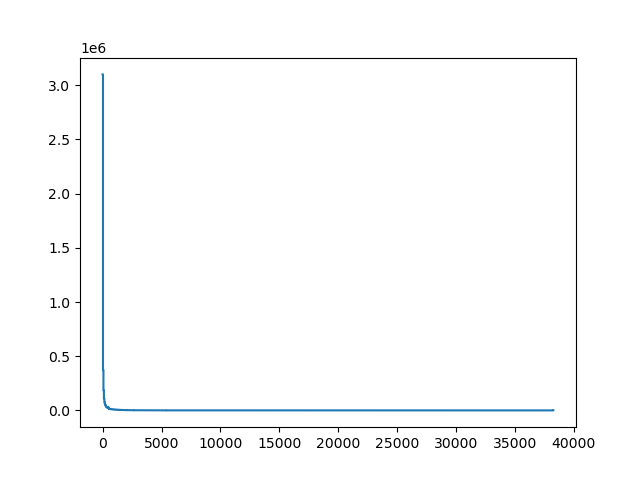

In [21]:
nfigure()
ic = i[:3000].compute()
ic.hist(bins=1000)